<a href="https://colab.research.google.com/github/DenisBoytsov41/tutors-sentiment-coursework/blob/refactor%2Fproject-structure/notebooks/02_extract_domain_texts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02_data_preparation.ipynb

## Этап 2. Подготовка данных

Цель ноутбука:
- привести все русскоязычные источники к единой схеме;
- нормализовать текстовые поля;
- аккуратно разделить источники по роли в проекте;
- подготовить чистые-версии данных для следующего этапа;
- не смешивать автоматически разные типы разметки.

## Важно
В этом ноутбуке мы:
- не обучаем модель;
- не строим финальный `train / validation / test`;
- не смешиваем автоматически emotional-метки CEDR с 3-классовой тональностью;
- не считаем финальные метрики.

Это этап **согласования и подготовки данных**.

In [ ]:
!pip -q install pandas pyarrow matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import ast
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

In [ ]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 200)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## 1. Пути проекта

In [ ]:
DRIVE_PROJECT_ROOT = Path("/content/drive/MyDrive/tutors_sentiment_project")

RAW_DIR = DRIVE_PROJECT_ROOT / "01_data_raw"
INTERIM_DIR = DRIVE_PROJECT_ROOT / "02_data_interim"

SOURCE_PASSPORTS_DIR = INTERIM_DIR / "source_passports"
UNIFIED_CORPUS_DIR = INTERIM_DIR / "unified_corpus"
CLEANED_DIR = INTERIM_DIR / "cleaned"
QC_REPORTS_DIR = INTERIM_DIR / "qc_reports"
FIGURES_DIR = QC_REPORTS_DIR / "figures"

SOURCE_PASSPORTS_DIR.mkdir(parents=True, exist_ok=True)
UNIFIED_CORPUS_DIR.mkdir(parents=True, exist_ok=True)
CLEANED_DIR.mkdir(parents=True, exist_ok=True)
QC_REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("RAW_DIR          =", RAW_DIR)
print("UNIFIED_CORPUS   =", UNIFIED_CORPUS_DIR)
print("CLEANED_DIR      =", CLEANED_DIR)
print("QC_REPORTS_DIR   =", QC_REPORTS_DIR)
print("FIGURES_DIR      =", FIGURES_DIR)

RAW_DIR          = /content/drive/MyDrive/tutors_sentiment_project/01_data_raw
UNIFIED_CORPUS   = /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/unified_corpus
CLEANED_DIR      = /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/cleaned
QC_REPORTS_DIR   = /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/qc_reports
FIGURES_DIR      = /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/qc_reports/figures


## 2. Реестр источников

In [ ]:
DATASET_REGISTRY = {
    "rusentiment": {
        "folder": RAW_DIR / "rusentiment",
        "group": "sentiment_core",
        "priority": "core",
        "target_usage": "основной базовый 3-классовый sentiment-источник",
    },
    "rusentitweet": {
        "folder": RAW_DIR / "rusentitweet",
        "group": "sentiment_core",
        "priority": "core",
        "target_usage": "дополнительный 3-классовый sentiment-источник после очистки и приведения меток",
    },
    "cedr_ru": {
        "folder": RAW_DIR / "cedr_ru",
        "group": "emotion_aux",
        "priority": "aux",
        "target_usage": "дополнительный emotional-корпус; не смешивать автоматически с sentiment",
    },
    "student_feedback_ru": {
        "folder": RAW_DIR / "student_feedback_ru",
        "group": "domain_education",
        "priority": "domain",
        "target_usage": "образовательный аспектный корпус; использовать как доменный источник",
    },
    "instructional_dialogues_ru": {
        "folder": RAW_DIR / "instructional_dialogues_ru",
        "group": "domain_dialogue_aux",
        "priority": "aux_domain",
        "target_usage": "вспомогательный диалоговый источник",
    },
    "teacher_student_dialogues_ru": {
        "folder": RAW_DIR / "teacher_student_dialogues_ru",
        "group": "domain_dialogue_core",
        "priority": "domain_core",
        "target_usage": "основной доменно близкий student-teacher диалоговый источник",
    },
    "local_domain_ru": {
        "folder": RAW_DIR / "local_domain_ru",
        "group": "local_domain",
        "priority": "future_core",
        "target_usage": "будущий реальный корпус ИС Тьюторы",
    },
}

registry_df = pd.DataFrame([
    {
        "dataset_name": name,
        "folder": str(meta["folder"]),
        "group": meta["group"],
        "priority": meta["priority"],
        "target_usage": meta["target_usage"],
    }
    for name, meta in DATASET_REGISTRY.items()
])

display(registry_df)

,dataset_name,folder,group,priority,target_usage
0,rusentiment,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/rusentiment,sentiment_core,core,основной базовый 3-классовый sentiment-источник
1,rusentitweet,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/rusentitweet,sentiment_core,core,дополнительный 3-классовый sentiment-источник после очистки и приведения меток
2,cedr_ru,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/cedr_ru,emotion_aux,aux,дополнительный emotional-корпус; не смешивать автоматически с sentiment
3,student_feedback_ru,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/student_feedback_ru,domain_education,domain,образовательный аспектный корпус; использовать как доменный источник
4,instructional_dialogues_ru,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/instructional_dialogues_ru,domain_dialogue_aux,aux_domain,вспомогательный диалоговый источник
5,teacher_student_dialogues_ru,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/teacher_student_dialogues_ru,domain_dialogue_core,domain_core,основной доменно близкий student-teacher диалоговый источник
6,local_domain_ru,/content/drive/MyDrive/tutors_sentiment_project/01_data_raw/local_domain_ru,local_domain,future_core,будущий реальный корпус ИС Тьюторы


## 3. Вспомогательные функции

In [ ]:
TEXT_COLUMN_CANDIDATES = [
    "text", "sentence", "content", "message", "comment", "review",
    "utterance", "post", "body"
]

LABEL_COLUMN_CANDIDATES = [
    "label", "labels", "sentiment", "class", "target", "emotion", "category"
]

ROLE_COLUMN_CANDIDATES = [
    "speaker_role", "role", "speaker", "author_role"
]

CONVERSATION_COLUMN_CANDIDATES = [
    "conversation_id", "dialog_id", "pair_id", "thread_id", "chat_id"
]

TURN_COLUMN_CANDIDATES = [
    "turn_id", "message_id", "utterance_id"
]

SPLIT_HINTS = ["train", "validation", "valid", "val", "dev", "test", "template"]

In [ ]:
# ищет, какие файлы читать в папке
def list_preferred_files(folder):
    if not folder.exists():
        return []

    csv_files = sorted(folder.glob("*.csv"))
    if csv_files:
        return csv_files

    parquet_files = sorted(folder.glob("*.parquet"))
    if parquet_files:
        return parquet_files

    return []

# читает csv или parquet
def read_table(path):
    suffix = path.suffix.lower()

    if suffix == ".csv":
        try:
            return pd.read_csv(path, low_memory=False)
        except Exception:
            return pd.read_csv(path, sep=";", low_memory=False)

    if suffix == ".parquet":
        return pd.read_parquet(path)

    raise ValueError(f"Неподдерживаемый формат: {path}")

# пытается определить нужную колонку по списку допустимых имён
def infer_column(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for candidate in candidates:
        if candidate in lower_map:
            return lower_map[candidate]
    return None

# пытается угадать split по имени файла
def infer_split_from_filename(path):
    name = path.stem.lower()
    for split_name in SPLIT_HINTS:
        if split_name in name:
            return split_name
    return "unknown"


def normalize_spaces(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
URL_RE = re.compile(r"http[s]?://\S+|www\.\S+")
HTML_RE = re.compile(r"<[^>]+>")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
MULTISPACE_RE = re.compile(r"\s+")
CYR_RE = re.compile(r"[А-Яа-яЁё]")
LAT_RE = re.compile(r"[A-Za-z]")

# функции очистки и текстовой диагностики
def clean_text_soft(text):
    """
    - убираем HTML
    - убираем URL
    - убираем mentions
    - в хэштегах сохраняем слово без #
    - нормализуем пробелы
    - регистр не трогаем
    """
    text = normalize_spaces(text)
    if not text:
        return ""

    text = re.sub(HTML_RE, " ", text)
    text = re.sub(URL_RE, " ", text)
    text = re.sub(MENTION_RE, " ", text)
    text = re.sub(HASHTAG_RE, r"\1", text)
    text = re.sub(MULTISPACE_RE, " ", text).strip()

    return text

# функции подсчёта кириллицы и латиницы
def count_cyrillic(text):
    return len(CYR_RE.findall(text))


def count_latin(text):
    return len(LAT_RE.findall(text))


def safe_word_count(text):
    if not text:
        return 0
    return len(text.split())

In [ ]:
# как приводить raw-метки к целевым классам
TARGET_LABEL_MAP = {
    "positive": "positive",
    "negative": "negative",
    "neutral": "neutral",
    "pos": "positive",
    "neg": "negative",
    "neu": "neutral",
    "1": "positive",
    "0": "neutral",
    "-1": "negative",
    "speech": None,
    "skip": None,
    "speech_act": None,
}

# как унифицировать роли
ROLE_MAP = {
    "teacher": "teacher_analog",
    "teacher_analog": "teacher_analog",
    "student": "student",
    "user": "student",
    "assistant": "teacher_analog",
    "tutor": "tutor",
    "tutor_analog": "tutor_analog",
}

def map_to_target_label(raw_label):
    if pd.isna(raw_label):
        return None
    key = str(raw_label).strip().lower()
    return TARGET_LABEL_MAP.get(key, None)


def normalize_role(x):
    if pd.isna(x):
        return None
    key = str(x).strip().lower()
    return ROLE_MAP.get(key, key)

In [ ]:
# умеет разбирать многометочные значения
def parse_list_like(x):
    """
    Для CEDR:
    поддерживаем форматы
    [], [1], [1 4], ['joy', 'sadness']
    """
    if pd.isna(x):
        return []

    if isinstance(x, list):
        return x

    if isinstance(x, tuple):
        return list(x)

    s = str(x).strip()

    if not s or s == "[]":
        return []

    if s.startswith("[") and s.endswith("]"):
        inner = s[1:-1].strip()
        if not inner:
            return []

        try:
            value = ast.literal_eval(s)
            if isinstance(value, list):
                return value
            if isinstance(value, tuple):
                return list(value)
        except Exception:
            pass

        tokens = re.findall(r"[A-Za-zА-Яа-яЁё0-9_]+", inner)
        return tokens

    return [s]

# безопасно превращает служебные структуры в JSON-строку
def to_json_safe(obj):
    return json.dumps(obj, ensure_ascii=False)

## 4. Функции подготовки по каждому датасету

In [ ]:
# Задаёv единый набор колонок, который должен быть у всех источников
# привести разные текстовые датасеты к одной схеме
COMMON_COLUMNS = [
    "dataset_name",
    "source_group",
    "priority",
    "source_file",
    "split",
    "conversation_id",
    "turn_id",
    "speaker_role",
    "text_raw",
    "text_clean",
    "raw_label",
    "target_label",
    "label_type",
    "meta_json",
]

In [ ]:
# Создаёт каркас датафрейма с общими служебными полями
# имя датасета,группа,приоритет,имя исходного файла,split.
def make_base_frame(dataset_name, source_group, priority, path, n_rows):
    return pd.DataFrame({
        "dataset_name": [dataset_name] * n_rows,
        "source_group": [source_group] * n_rows,
        "priority": [priority] * n_rows,
        "source_file": [path.name] * n_rows,
        "split": [infer_split_from_filename(path)] * n_rows,
    })


# Гарантирует, что: все COMMON_COLUMNS присутствуют, порядок колонок одинаковый,
# text_raw и text_clean приведены к строкам.
def finalize_common_frame(df):
    for col in COMMON_COLUMNS:
        if col not in df.columns:
            df[col] = None

    df = df[COMMON_COLUMNS].copy()
    df["text_raw"] = df["text_raw"].fillna("").astype(str)
    df["text_clean"] = df["text_clean"].fillna("").astype(str)

    return df

In [ ]:
# Берёт файл RuSentiment и приводит его к общей схеме:
# текст идёт в text_raw, очищенный текст — в text_clean,
# исходная метка — в raw_label, приведённая к целевой задаче — в target_label,
# тип метки помечается как sentiment_3class_candidate
def prepare_rusentiment(path):
    df = read_table(path).copy()

    base = make_base_frame(
        dataset_name="rusentiment",
        source_group="sentiment_core",
        priority="core",
        path=path,
        n_rows=len(df),
    )

    base["conversation_id"] = None
    base["turn_id"] = None
    base["speaker_role"] = None
    base["text_raw"] = df["text"].map(normalize_spaces)
    base["text_clean"] = base["text_raw"].map(clean_text_soft)
    base["raw_label"] = df["label"].astype(str)
    base["target_label"] = base["raw_label"].map(map_to_target_label)
    base["label_type"] = "sentiment_3class_candidate"
    base["meta_json"] = "{}"

    return finalize_common_frame(base)

In [ ]:
# То же самое, что предыдущая ячейка, но для RuSentiTweet
def prepare_rusentitweet(path):
    df = read_table(path).copy()

    base = make_base_frame(
        dataset_name="rusentitweet",
        source_group="sentiment_core",
        priority="core",
        path=path,
        n_rows=len(df),
    )

    base["conversation_id"] = None
    base["turn_id"] = df["id"] if "id" in df.columns else None
    base["speaker_role"] = None
    base["text_raw"] = df["text"].map(normalize_spaces)
    base["text_clean"] = base["text_raw"].map(clean_text_soft)
    base["raw_label"] = df["label"].astype(str)
    base["target_label"] = base["raw_label"].map(map_to_target_label)
    base["label_type"] = "sentiment_3class_candidate"
    base["meta_json"] = "{}"

    return finalize_common_frame(base)

In [ ]:
# функция читает CEDR и приводит его к общей схеме
def prepare_cedr(path):
    df = read_table(path).copy()

    base = make_base_frame(
        dataset_name="cedr_ru",
        source_group="emotion_aux",
        priority="aux",
        path=path,
        n_rows=len(df),
    )

    parsed_labels = df["labels"].map(parse_list_like) if "labels" in df.columns else [[] for _ in range(len(df))]
    num_labels = pd.Series(parsed_labels).map(len)

    meta = []
    for i in range(len(df)):
        meta.append({
            "cedr_source": df["source"].iloc[i] if "source" in df.columns else None,
            "cedr_labels_parsed": parsed_labels.iloc[i] if hasattr(parsed_labels, "iloc") else parsed_labels[i],
            "cedr_num_labels": int(num_labels.iloc[i]) if hasattr(num_labels, "iloc") else int(num_labels[i]),
        })

    base["conversation_id"] = None
    base["turn_id"] = None
    base["speaker_role"] = None
    base["text_raw"] = df["text"].map(normalize_spaces)
    base["text_clean"] = base["text_raw"].map(clean_text_soft)
    base["raw_label"] = df["labels"].astype(str) if "labels" in df.columns else None
    base["target_label"] = None
    base["label_type"] = "emotion_multilabel"
    base["meta_json"] = [to_json_safe(x) for x in meta]

    return finalize_common_frame(base)

In [ ]:
# Эта функция готовит student_feedback_ru в document-level виде
def prepare_student_feedback_document_level(path):
    df = read_table(path).copy()

    base = make_base_frame(
        dataset_name="student_feedback_ru",
        source_group="domain_education",
        priority="domain",
        path=path,
        n_rows=len(df),
    )

    aspect_cols = [c for c in df.columns if c != "text"]

    meta = []
    for _, row in df.iterrows():
        aspect_payload = {}
        for col in aspect_cols:
            val = row[col]
            if pd.notna(val):
                aspect_payload[col] = val
        meta.append({
            "aspect_labels": aspect_payload
        })

    base["conversation_id"] = None
    base["turn_id"] = None
    base["speaker_role"] = "student"
    base["text_raw"] = df["text"].map(normalize_spaces)
    base["text_clean"] = base["text_raw"].map(clean_text_soft)
    base["raw_label"] = None
    base["target_label"] = None
    base["label_type"] = "education_aspect_document"
    base["meta_json"] = [to_json_safe(x) for x in meta]

    return finalize_common_frame(base)

In [ ]:
# Эта функция строит из student_feedback_ru длинную аспектную формe
# одна строка исходного отзыва превращается в несколько строк,
# по одной строке на каждый аспект, который не пустой.
def build_student_feedback_long(path):
    df = read_table(path).copy()

    aspect_cols = [c for c in df.columns if c != "text"]
    rows = []

    for idx, row in df.iterrows():
        text_raw = normalize_spaces(row["text"])
        text_clean = clean_text_soft(text_raw)

        for aspect in aspect_cols:
            val = row[aspect]
            if pd.isna(val):
                continue

            rows.append({
                "dataset_name": "student_feedback_ru",
                "source_group": "domain_education",
                "priority": "domain",
                "source_file": path.name,
                "split": infer_split_from_filename(path),
                "conversation_id": None,
                "turn_id": idx,
                "speaker_role": "student",
                "text_raw": text_raw,
                "text_clean": text_clean,
                "raw_label": str(val),
                "target_label": None,
                "label_type": "education_aspect_long",
                "meta_json": to_json_safe({
                    "aspect_name": aspect,
                    "aspect_value": val
                }),
            })

    out = pd.DataFrame(rows)
    if out.empty:
        out = pd.DataFrame(columns=COMMON_COLUMNS)

    return finalize_common_frame(out)

In [ ]:
# Готовим instructional_dialogues_ru к общей схеме
def prepare_instructional_dialogues(path):
    df = read_table(path).copy()

    base = make_base_frame(
        dataset_name="instructional_dialogues_ru",
        source_group="domain_dialogue_aux",
        priority="aux_domain",
        path=path,
        n_rows=len(df),
    )

    meta = []
    for _, row in df.iterrows():
        meta.append({
            "topic": row["topic"] if "topic" in df.columns else None,
            "goal": row["goal"] if "goal" in df.columns else None,
        })

    base["conversation_id"] = df["conversation_id"] if "conversation_id" in df.columns else None
    base["turn_id"] = df["turn_id"] if "turn_id" in df.columns else None
    base["speaker_role"] = df["speaker_role"].map(normalize_role) if "speaker_role" in df.columns else None
    base["text_raw"] = df["text"].map(normalize_spaces)
    base["text_clean"] = base["text_raw"].map(clean_text_soft)
    base["raw_label"] = None
    base["target_label"] = None
    base["label_type"] = "unlabeled_dialogue"
    base["meta_json"] = [to_json_safe(x) for x in meta]

    return finalize_common_frame(base)

In [ ]:
# Подготавливает teacher_student_dialogues_ru к общей схеме
def prepare_teacher_student_dialogues(path):
    df = read_table(path).copy()

    base = make_base_frame(
        dataset_name="teacher_student_dialogues_ru",
        source_group="domain_dialogue_core",
        priority="domain_core",
        path=path,
        n_rows=len(df),
    )

    meta = []
    for _, row in df.iterrows():
        meta.append({
            "theme": row["theme"] if "theme" in df.columns else None,
            "original_theme": row["original_theme"] if "original_theme" in df.columns else None,
        })

    base["conversation_id"] = df["conversation_id"] if "conversation_id" in df.columns else None
    base["turn_id"] = df["turn_id"] if "turn_id" in df.columns else None
    base["speaker_role"] = df["speaker_role"].map(normalize_role) if "speaker_role" in df.columns else None
    base["text_raw"] = df["text"].map(normalize_spaces)
    base["text_clean"] = base["text_raw"].map(clean_text_soft)
    base["raw_label"] = None
    base["target_label"] = None
    base["label_type"] = "unlabeled_dialogue"
    base["meta_json"] = [to_json_safe(x) for x in meta]

    return finalize_common_frame(base)

In [ ]:
# Подготавливает local_domain_ru, то есть будущий локальный корпус ИС.
def prepare_local_domain(path):
    df = read_table(path).copy()

    base = make_base_frame(
        dataset_name="local_domain_ru",
        source_group="local_domain",
        priority="future_core",
        path=path,
        n_rows=len(df),
    )

    meta = []
    for _, row in df.iterrows():
        meta.append({
            "meta": row["meta"] if "meta" in df.columns else None
        })

    base["conversation_id"] = df["conversation_id"] if "conversation_id" in df.columns else None
    base["turn_id"] = df["turn_id"] if "turn_id" in df.columns else None
    base["speaker_role"] = df["speaker_role"].map(normalize_role) if "speaker_role" in df.columns else None
    base["text_raw"] = df["text"].map(normalize_spaces)
    base["text_clean"] = base["text_raw"].map(clean_text_soft)
    base["raw_label"] = None
    base["target_label"] = None
    base["label_type"] = "unlabeled_dialogue"
    base["meta_json"] = [to_json_safe(x) for x in meta]

    return finalize_common_frame(base)

## 5. Загрузка и подготовка всех источников

In [ ]:
# массовая загрузка всех источников
# превращает набор разрозненных файлов в согласованные рабочие таблицы

prepared_parts = {
    "all_sources": [],
    "student_feedback_long": [],
}

load_errors = []

for dataset_name, meta in DATASET_REGISTRY.items():
    files = list_preferred_files(meta["folder"])

    for path in files:
        try:
            if dataset_name == "rusentiment":
                prepared_parts["all_sources"].append(prepare_rusentiment(path))

            elif dataset_name == "rusentitweet":
                prepared_parts["all_sources"].append(prepare_rusentitweet(path))

            elif dataset_name == "cedr_ru":
                prepared_parts["all_sources"].append(prepare_cedr(path))

            elif dataset_name == "student_feedback_ru":
                prepared_parts["all_sources"].append(prepare_student_feedback_document_level(path))
                prepared_parts["student_feedback_long"].append(build_student_feedback_long(path))

            elif dataset_name == "instructional_dialogues_ru":
                prepared_parts["all_sources"].append(prepare_instructional_dialogues(path))

            elif dataset_name == "teacher_student_dialogues_ru":
                prepared_parts["all_sources"].append(prepare_teacher_student_dialogues(path))

            elif dataset_name == "local_domain_ru":
                prepared_parts["all_sources"].append(prepare_local_domain(path))

        except Exception as e:
            load_errors.append({
                "dataset_name": dataset_name,
                "path": str(path),
                "error": str(e),
            })

all_sources_df = pd.concat(prepared_parts["all_sources"], ignore_index=True) if prepared_parts["all_sources"] else pd.DataFrame(columns=COMMON_COLUMNS)
student_feedback_long_df = pd.concat(prepared_parts["student_feedback_long"], ignore_index=True) if prepared_parts["student_feedback_long"] else pd.DataFrame(columns=COMMON_COLUMNS)
load_errors_df = pd.DataFrame(load_errors)

print("all_sources_df shape:", all_sources_df.shape)
print("student_feedback_long_df shape:", student_feedback_long_df.shape)

if not load_errors_df.empty:
    display(load_errors_df)

display(all_sources_df.head(10))

all_sources_df shape: (121708, 14)
student_feedback_long_df shape: (24206, 14)


,dataset_name,source_group,priority,source_file,split,conversation_id,turn_id,speaker_role,text_raw,text_clean,raw_label,target_label,label_type,meta_json
0,rusentiment,sentiment_core,core,rusentiment_preselected_posts.csv,unknown,None,None,None,Прорвём информационную блокаду изнутри.,Прорвём информационную блокаду изнутри.,neutral,neutral,sentiment_3class_candidate,{}
1,rusentiment,sentiment_core,core,rusentiment_preselected_posts.csv,unknown,None,None,None,"Никогда у меня не будет ""одного приложения для всего"". В топку эти ущербные универсальности.","Никогда у меня не будет ""одного приложения для всего"". В топку эти ущербные универсальности.",negative,negative,sentiment_3class_candidate,{}
2,rusentiment,sentiment_core,core,rusentiment_preselected_posts.csv,unknown,None,None,None,"Кури-и тебя не укусит злая собака, потому что ты воняешь,кури-и тебя не ограбят,так как ты испугаешь грабителей отвратительным громким кашлем, кури - и ты не умрешь от старости, просто не доживешь...","Кури-и тебя не укусит злая собака, потому что ты воняешь,кури-и тебя не ограбят,так как ты испугаешь грабителей отвратительным громким кашлем, кури - и ты не умрешь от старости, просто не доживешь...",skip,None,sentiment_3class_candidate,{}
3,rusentiment,sentiment_core,core,rusentiment_preselected_posts.csv,unknown,None,None,None,"Есть 3 типа людей: Умные, которые делают все сразу. Умные, которые откладывают на потом и доделывают. И Я...сначала впадлу потом поздно","Есть 3 типа людей: Умные, которые делают все сразу. Умные, которые откладывают на потом и доделывают. И Я...сначала впадлу потом поздно",neutral,neutral,sentiment_3class_candidate,{}
4,rusentiment,sentiment_core,core,rusentiment_preselected_posts.csv,unknown,None,None,None,мегафон чет накрыло,мегафон чет накрыло,neutral,neutral,sentiment_3class_candidate,{}
5,rusentiment,sentiment_core,core,rusentiment_preselected_posts.csv,unknown,None,None,None,"Блин, все как с ума посходили с этими рисунками на стенах. Заходишь в ""Новости"", как в Третьяковскую галерею...","Блин, все как с ума посходили с этими рисунками на стенах. Заходишь в ""Новости"", как в Третьяковскую галерею...",skip,None,sentiment_3class_candidate,{}
6,rusentiment,sentiment_core,core,rusentiment_preselected_posts.csv,unknown,None,None,None,"Они любили только лето. Они мёрзли, но не сдавались. На дворе было 124-е августа..","Они любили только лето. Они мёрзли, но не сдавались. На дворе было 124-е августа..",skip,None,sentiment_3class_candidate,{}
7,rusentiment,sentiment_core,core,rusentiment_preselected_posts.csv,unknown,None,None,None,Шах и мат.,Шах и мат.,neutral,neutral,sentiment_3class_candidate,{}
8,rusentiment,sentiment_core,core,rusentiment_preselected_posts.csv,unknown,None,None,None,"Просто в дрожь бросает. Как можно быть такими тупыми? От хохлянских фразочек я офигеваю, а от школярского голоса да и этих кортавых фраз я вообще херею..","Просто в дрожь бросает. Как можно быть такими тупыми? От хохлянских фразочек я офигеваю, а от школярского голоса да и этих кортавых фраз я вообще херею..",negative,negative,sentiment_3class_candidate,{}
9,rusentiment,sentiment_core,core,rusentiment_preselected_posts.csv,unknown,None,None,None,"косяк, я соскучилась по тебе (","косяк, я соскучилась по тебе (",positive,positive,sentiment_3class_candidate,{}


## 6. Первичные проверки после приведения к единой схеме

In [ ]:
# Проверяем, что в all_sources_df действительно существуют все колонки из COMMON_COLUMNS

schema_check_df = pd.DataFrame({
    "column": COMMON_COLUMNS,
    "exists_in_all_sources_df": [col in all_sources_df.columns for col in COMMON_COLUMNS],
})

display(schema_check_df)

,column,exists_in_all_sources_df
0,dataset_name,True
1,source_group,True
2,priority,True
3,source_file,True
4,split,True
5,conversation_id,True
6,turn_id,True
7,speaker_role,True
8,text_raw,True
9,text_clean,True


In [ ]:
# Собирает агрегированную сводку по подготовленным данным:
# по датасету,по группе источника,по приоритету,по типу метки.
# Считает:число строк,число непустых текстов,число строк с целевой меткой,
# число уникальных файлов.

prepared_summary_df = (
    all_sources_df.groupby(["dataset_name", "source_group", "priority", "label_type"], dropna=False)
    .agg(
        rows=("text_clean", "size"),
        non_empty_clean_texts=("text_clean", lambda s: int((s.str.len() > 0).sum())),
        rows_with_target_label=("target_label", lambda s: int(s.notna().sum())),
        unique_source_files=("source_file", "nunique"),
    )
    .reset_index()
    .sort_values(["source_group", "dataset_name"])
)

display(prepared_summary_df)

,dataset_name,source_group,priority,label_type,rows,non_empty_clean_texts,rows_with_target_label,unique_source_files
1,instructional_dialogues_ru,domain_dialogue_aux,aux_domain,unlabeled_dialogue,400,400,0,1
6,teacher_student_dialogues_ru,domain_dialogue_core,domain_core,unlabeled_dialogue,66045,66045,0,1
5,student_feedback_ru,domain_education,domain,education_aspect_document,1274,1274,0,3
0,cedr_ru,emotion_aux,aux,emotion_multilabel,9410,9410,0,2
2,local_domain_ru,local_domain,future_core,unlabeled_dialogue,2,2,0,1
3,rusentiment,sentiment_core,core,sentiment_3class_candidate,31185,31185,23278,3
4,rusentitweet,sentiment_core,core,sentiment_3class_candidate,13392,13392,11053,3


## 7. Очистка текстов: насколько поменялись строки

In [ ]:
# Создаёт отдельную QC-копию all_sources_df, чтобы не портить основной рабочий датафрейм
# В ней считаются:изменился ли текст после очистки,длина сырого текста,
# длина очищенного текста,число слов после очистки.
# Потом строится cleaning_effect_df:сколько строк изменилось,сколько стало пустыми,
# средняя длина до и после,доля изменённых строк.

cleaning_qc_df = all_sources_df.copy()

cleaning_qc_df["changed_after_cleaning"] = (
    cleaning_qc_df["text_raw"] != cleaning_qc_df["text_clean"]
).astype(int)

cleaning_qc_df["raw_len_chars"] = cleaning_qc_df["text_raw"].str.len()
cleaning_qc_df["clean_len_chars"] = cleaning_qc_df["text_clean"].str.len()
cleaning_qc_df["clean_len_words"] = cleaning_qc_df["text_clean"].map(safe_word_count)

cleaning_effect_df = (
    cleaning_qc_df.groupby("dataset_name")
    .agg(
        rows=("text_clean", "size"),
        changed_rows=("changed_after_cleaning", "sum"),
        empty_after_cleaning=("text_clean", lambda s: int((s.str.len() == 0).sum())),
        mean_raw_len=("raw_len_chars", "mean"),
        mean_clean_len=("clean_len_chars", "mean"),
        mean_clean_words=("clean_len_words", "mean"),
    )
    .reset_index()
)

cleaning_effect_df["changed_share"] = cleaning_effect_df["changed_rows"] / cleaning_effect_df["rows"]
cleaning_effect_df = cleaning_effect_df.round(4)

display(cleaning_effect_df)

,dataset_name,rows,changed_rows,empty_after_cleaning,mean_raw_len,mean_clean_len,mean_clean_words,changed_share
0,cedr_ru,9410,136,0,92.3015,92.2657,14.7750,0.0145
1,instructional_dialogues_ru,400,0,0,14.7100,14.7100,2.7500,0.0000
2,local_domain_ru,2,0,0,51.0000,51.0000,7.5000,0.0000
3,rusentiment,31185,517,0,81.6512,81.5853,12.7911,0.0166
4,rusentitweet,13392,10322,0,59.0704,44.4957,7.5189,0.7708
5,student_feedback_ru,1274,2,0,430.0997,430.0589,62.1115,0.0016
6,teacher_student_dialogues_ru,66045,87,0,330.3533,330.3502,46.5170,0.0013


In [ ]:
# Показывает примеры строк, которые изменились после очистки.
changed_examples_df = cleaning_qc_df[
    cleaning_qc_df["changed_after_cleaning"] == 1
][["dataset_name", "source_file", "text_raw", "text_clean"]].head(50)

display(changed_examples_df)

,dataset_name,source_file,text_raw,text_clean
86,rusentiment,rusentiment_preselected_posts.csv,Маловато будет =( #ДеньРадио,Маловато будет =( ДеньРадио
416,rusentiment,rusentiment_preselected_posts.csv,"Сегодня играл в сцене, где делал девушке предложение, но и даже постановочная ситуация заставила осознать последствия этого рокового шага. Романтично конечно, но где-то там романтика и заканчивает...","Сегодня играл в сцене, где делал девушке предложение, но и даже постановочная ситуация заставила осознать последствия этого рокового шага. Романтично конечно, но где-то там романтика и заканчивает..."
431,rusentiment,rusentiment_preselected_posts.csv,"Щас все люди фотографируются с сиренью, не а я что не человек🦄✨😇🤗🍒 ------------------ Берегите в себе человека.🏵💐 @А. Чехов.","Щас все люди фотографируются с сиренью, не а я что не человек🦄✨😇🤗🍒 ------------------ Берегите в себе человека.🏵💐 . Чехов."
649,rusentiment,rusentiment_preselected_posts.csv,"Сегодня в Москве Die Antwoord... а я на работе. Ебать, я лох. #FML","Сегодня в Москве Die Antwoord... а я на работе. Ебать, я лох. FML"
731,rusentiment,rusentiment_preselected_posts.csv,"А что Вы будете делать, если завтра наступит #зомби - #апокалипсис ?","А что Вы будете делать, если завтра наступит зомби - апокалипсис ?"
767,rusentiment,rusentiment_preselected_posts.csv,"Тьфу блин! Теперь до октября ждать, кого там Ниган замочил 😨 #TWDFinale #negan","Тьфу блин! Теперь до октября ждать, кого там Ниган замочил 😨 TWDFinale negan"
897,rusentiment,rusentiment_preselected_posts.csv,"xxx: когда-нибудь докажут, что все живые существа, включая растения, грибы и бактерии, чувствуют боль и тогда появятся супер-вегетарианцы, не едящие ничего, и живущие за счет солнечного света xxx:...","xxx: когда-нибудь докажут, что все живые существа, включая растения, грибы и бактерии, чувствуют боль и тогда появятся супер-вегетарианцы, не едящие ничего, и живущие за счет солнечного света xxx:..."
991,rusentiment,rusentiment_preselected_posts.csv,"Совсем не хочется постить политоту и разводить срачЪ™, но с моей точки зрения, это один из самых сильных визуальных образов за весь украинский кризис. #Запорожье","Совсем не хочется постить политоту и разводить срачЪ™, но с моей точки зрения, это один из самых сильных визуальных образов за весь украинский кризис. Запорожье"
1096,rusentiment,rusentiment_preselected_posts.csv,"Вчера любимая сказала: ""-- сел бы хоть стих написал"" так собственно вот: Типа #Хоку ;) В лесу лесу скучном Стояла берёза Мы её спиляли Веселей не стало.","Вчера любимая сказала: ""-- сел бы хоть стих написал"" так собственно вот: Типа Хоку ;) В лесу лесу скучном Стояла берёза Мы её спиляли Веселей не стало."
1212,rusentiment,rusentiment_preselected_posts.csv,#IceBucketChallenge #КПИведро Это дошло и до простых смертных студентов☺️,IceBucketChallenge КПИведро Это дошло и до простых смертных студентов☺️


## 8. Core sentiment-источники: фильтрация до целевых 3 классов

In [ ]:
# из all_sources_df выбираются только источники с source_group == "sentiment_core"
# считается объём до фильтрации; оставляются только строки, где target_label не пустой;
# убираются строки с пустым text_clean; считается объём после фильтрации;
# строится summary-таблица sentiment_core_filter_df

#  здесь sentiment-источники превращаются из сырых тональных наборов в ядро 3-классовой задачи.

sentiment_core_df = all_sources_df[
    all_sources_df["source_group"] == "sentiment_core"
].copy()

sentiment_core_before_df = (
    sentiment_core_df.groupby("dataset_name")
    .size()
    .reset_index(name="rows_before_filter")
)

sentiment_core_df = sentiment_core_df[
    sentiment_core_df["target_label"].notna()
].copy()

sentiment_core_df = sentiment_core_df[
    sentiment_core_df["text_clean"].str.len() > 0
].copy()

sentiment_core_after_df = (
    sentiment_core_df.groupby("dataset_name")
    .size()
    .reset_index(name="rows_after_filter")
)

sentiment_core_filter_df = sentiment_core_before_df.merge(
    sentiment_core_after_df,
    on="dataset_name",
    how="left"
).fillna(0)

sentiment_core_filter_df["rows_after_filter"] = sentiment_core_filter_df["rows_after_filter"].astype(int)
sentiment_core_filter_df["kept_share"] = (
    sentiment_core_filter_df["rows_after_filter"] / sentiment_core_filter_df["rows_before_filter"]
).round(4)

display(sentiment_core_filter_df)

,dataset_name,rows_before_filter,rows_after_filter,kept_share
0,rusentiment,31185,23278,0.7464
1,rusentitweet,13392,11053,0.8253


In [ ]:
# показывает распределение по target_label внутри sentiment_core_df

sentiment_label_dist_df = (
    sentiment_core_df.groupby(["dataset_name", "target_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["dataset_name", "count"], ascending=[True, False])
)

display(sentiment_label_dist_df)

,dataset_name,target_label,count
1,rusentiment,neutral,12720
2,rusentiment,positive,6646
0,rusentiment,negative,3912
4,rusentitweet,neutral,5341
3,rusentitweet,negative,3298
5,rusentitweet,positive,2414


## 9. CEDR оставляем отдельно как emotional auxiliary corpus

In [ ]:
# Берёт только строки CEDR из all_sources_df, а потом достаёт из meta_json:
# исходный source,число меток,распарсенные метки,очищенный текст

cedr_prepared_df = all_sources_df[
    all_sources_df["dataset_name"] == "cedr_ru"
].copy()

cedr_meta_rows = []
for _, row in cedr_prepared_df.head(20).iterrows():
    meta = json.loads(row["meta_json"])
    cedr_meta_rows.append({
        "source_file": row["source_file"],
        "raw_label": row["raw_label"],
        "cedr_num_labels": meta.get("cedr_num_labels"),
        "cedr_labels_parsed": meta.get("cedr_labels_parsed"),
        "text_clean": row["text_clean"],
    })

cedr_meta_preview_df = pd.DataFrame(cedr_meta_rows)
display(cedr_meta_preview_df)

,source_file,raw_label,cedr_num_labels,cedr_labels_parsed,text_clean
0,test.csv,[],0,[],Но выбор купания в таком случае — это лишь выбор меньшего из зол .
1,test.csv,[],0,[],"На поле , с которого должен был произойти вылет , уже воздвиглась огромная сигара аэровоза – удачно выкрашенная в геральдические цвета Великого Дракона ."
2,test.csv,[],0,[],Всем им грозит наказание в виде лишения свободы на срок до 15 лет или пожизненное заключение.
3,test.csv,[],0,[],"Некоторых зрительниц особенно разозлила демонстрация красной жидкости, выливаемой на гигиеническую прокладку."
4,test.csv,[3],1,[3],"Я в мае сдаю, боюсь сейчас) Ну как же, для себя, просто."
5,test.csv,[2],1,[2],"Недоумение вызвало, в частности, то, что судить поединок позвали популярного артиста Басту."
6,test.csv,[1],1,[1],"ужасное ощущение, вроде и вырубает, а заснуть норм не можешь ("
7,test.csv,[1],1,[1],"тут щя смишной анекдот рассказывали, а я один хуже всех — не смеюсь :("
8,test.csv,[2],1,[2],Биатлонист выразил недоумение отсутствием россиянина на олимпийской трассе в Южной Корее.
9,test.csv,[],0,[],"54-летний Мухаррем Индже придерживается светских взглядов, он также известен как яростный критик Эрдогана; является депутатом парламента от провинции Ялова."


## 10. Образовательный аспектный корпус: отдельно document-level и long-view

In [ ]:
# Эта ячейка берёт student_feedback_doc_df и делает его QC-копию:
# создаёт student_feedback_doc_qc_df;из meta_json достаёт словарь аспектов;
# считает num_aspects_filled;
# строит summary:число строк,среднее число аспектов,
# медиану числа аспектов,среднюю длину текста в словах;
# показывает summary и первые строки.

# Сначала выделяем document-level корпус student_feedback_ru
student_feedback_doc_df = all_sources_df[
    all_sources_df["dataset_name"] == "student_feedback_ru"
].copy()

# QC-копия для анализа, чтобы не засорять основной рабочий датафрейм
student_feedback_doc_qc_df = student_feedback_doc_df.copy()

student_feedback_doc_qc_df["num_aspects_filled"] = student_feedback_doc_qc_df["meta_json"].map(
    lambda x: len(json.loads(x).get("aspect_labels", {}))
)

student_feedback_doc_summary_df = pd.DataFrame({
    "rows": [len(student_feedback_doc_qc_df)],
    "mean_num_aspects_filled": [round(student_feedback_doc_qc_df["num_aspects_filled"].mean(), 4)],
    "median_num_aspects_filled": [round(student_feedback_doc_qc_df["num_aspects_filled"].median(), 4)],
    "mean_clean_words": [round(student_feedback_doc_qc_df["text_clean"].map(safe_word_count).mean(), 4)],
})

display(student_feedback_doc_summary_df)
display(student_feedback_doc_qc_df.head(5))

,rows,mean_num_aspects_filled,median_num_aspects_filled,mean_clean_words
0,1274,19.0,19.0,62.1115


,dataset_name,source_group,priority,source_file,split,conversation_id,turn_id,speaker_role,text_raw,text_clean,raw_label,target_label,label_type,meta_json,num_aspects_filled
53987,student_feedback_ru,domain_education,domain,test.csv,test,None,None,student,"Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...","Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...",None,None,education_aspect_document,"{""aspect_labels"": {""лекции"": 0, ""доклады"": 0, ""проекты"": 0, ""презентации"": 0, ""фильмы"": 0, ""видео-уроки"": 0, ""задания__задачи"": 0, ""онлайн-курс"": 0, ""баллы__оценки"": 0, ""практики__семинары"": 0, ""т...",19
53988,student_feedback_ru,domain_education,domain,test.csv,test,None,None,student,"Хороший преподаватель, интересные и полезные знания дает в этой области. Электив достаточно легкий, закрыться может каждый без лишних проблем.","Хороший преподаватель, интересные и полезные знания дает в этой области. Электив достаточно легкий, закрыться может каждый без лишних проблем.",None,None,education_aspect_document,"{""aspect_labels"": {""лекции"": 0, ""доклады"": 0, ""проекты"": 0, ""презентации"": 0, ""фильмы"": 0, ""видео-уроки"": 0, ""задания__задачи"": 0, ""онлайн-курс"": 0, ""баллы__оценки"": 0, ""практики__семинары"": 0, ""т...",19
53989,student_feedback_ru,domain_education,domain,test.csv,test,None,None,student,"Важно обязательно ходить на пары. Чтоб вас, как минимум, запомнила учительница. И не сидеть на них в телефоне, хоть иногда пару слов по теме кидать…. Иначе вы не закроете этот электив. И в конце в...","Важно обязательно ходить на пары. Чтоб вас, как минимум, запомнила учительница. И не сидеть на них в телефоне, хоть иногда пару слов по теме кидать…. Иначе вы не закроете этот электив. И в конце в...",None,None,education_aspect_document,"{""aspect_labels"": {""лекции"": 0, ""доклады"": 0, ""проекты"": 0, ""презентации"": 0, ""фильмы"": 1, ""видео-уроки"": 1, ""задания__задачи"": 0, ""онлайн-курс"": 0, ""баллы__оценки"": 1, ""практики__семинары"": 0, ""т...",19
53990,student_feedback_ru,domain_education,domain,test.csv,test,None,None,student,"Отличный электив! Преподаватель - умная, начитанная, любит работать со студентами, любит свою работу в целом. Курс позволяет изучить лексику по теме психология и логопедия, ну и соответственно узн...","Отличный электив! Преподаватель - умная, начитанная, любит работать со студентами, любит свою работу в целом. Курс позволяет изучить лексику по теме психология и логопедия, ну и соответственно узн...",None,None,education_aspect_document,"{""aspect_labels"": {""лекции"": 0, ""доклады"": 0, ""проекты"": 0, ""презентации"": 0, ""фильмы"": 0, ""видео-уроки"": 0, ""задания__задачи"": 0, ""онлайн-курс"": 0, ""баллы__оценки"": 0, ""практики__семинары"": 0, ""т...",19
53991,student_feedback_ru,domain_education,domain,test.csv,test,None,None,student,"преподша- Марандина Елена Леонидовна. Электив проходил в соцгуме. Электив нормальный, смотрите презентации, записываете лекции и иногда делаете мини-проверочные. По ощущениям-как подготовка к ОГЭ ...","преподша- Марандина Елена Леонидовна. Электив проходил в соцгуме. Электив нормальный, смотрите презентации, записываете лекции и иногда делаете мини-проверочные. По ощущениям-как подготовка к ОГЭ ...",None,None,education_aspect_document,"{""aspect_labels"": {""лекции"": 1, ""доклады"": 0, ""проекты"": 0, ""презентации"": 1, ""фильмы"": 0, ""видео-уроки"": 0, ""задания__задачи"": 0, ""онлайн-курс"": 0, ""баллы__оценки"": 0, ""практики__семинары"": 0, ""т...",19


In [ ]:
# Берём student_feedback_long_df — то есть длинную аспектную форму — и строит распределение по raw_label

# как выглядит разложение аспектов в длинной форме.

student_feedback_long_summary_df = (
    student_feedback_long_df.groupby("raw_label")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(student_feedback_long_summary_df.head(30))
display(student_feedback_long_df.head(10))

,raw_label,count
0,0,20579
2,2,1971
1,1,1188
3,3,468


,dataset_name,source_group,priority,source_file,split,conversation_id,turn_id,speaker_role,text_raw,text_clean,raw_label,target_label,label_type,meta_json
0,student_feedback_ru,domain_education,domain,test.csv,test,None,0,student,"Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...","Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...",0,None,education_aspect_long,"{""aspect_name"": ""лекции"", ""aspect_value"": 0}"
1,student_feedback_ru,domain_education,domain,test.csv,test,None,0,student,"Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...","Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...",0,None,education_aspect_long,"{""aspect_name"": ""доклады"", ""aspect_value"": 0}"
2,student_feedback_ru,domain_education,domain,test.csv,test,None,0,student,"Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...","Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...",0,None,education_aspect_long,"{""aspect_name"": ""проекты"", ""aspect_value"": 0}"
3,student_feedback_ru,domain_education,domain,test.csv,test,None,0,student,"Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...","Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...",0,None,education_aspect_long,"{""aspect_name"": ""презентации"", ""aspect_value"": 0}"
4,student_feedback_ru,domain_education,domain,test.csv,test,None,0,student,"Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...","Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...",0,None,education_aspect_long,"{""aspect_name"": ""фильмы"", ""aspect_value"": 0}"
5,student_feedback_ru,domain_education,domain,test.csv,test,None,0,student,"Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...","Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...",0,None,education_aspect_long,"{""aspect_name"": ""видео-уроки"", ""aspect_value"": 0}"
6,student_feedback_ru,domain_education,domain,test.csv,test,None,0,student,"Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в таком ...","Электив хороший, преподаватель тоже, но для меня полезного было не так много. Я записалась на него в тот момент, когда на одной из профильных дисциплин мы как раз изучали нейронки, причём в

## 11. Доменные диалоговые источники

In [ ]:
# Эта ячейка разделяет диалоговые данные на три части:
# domain_dialogues_core_prepared_df— это только teacher_student_dialogues_ru;
# domain_dialogues_aux_prepared_df— это только instructional_dialogues_ru;
# local_domain_template_prepared_df— это только local_domain_ru.
# После этого она строит dialogue_summary_df, где по каждому из них считает:
# роль в проекте,число строк,число уникальных диалогов,число ролей,среднюю длину текста

domain_dialogues_core_prepared_df = all_sources_df[
    all_sources_df["dataset_name"] == "teacher_student_dialogues_ru"
].copy()

domain_dialogues_aux_prepared_df = all_sources_df[
    all_sources_df["dataset_name"] == "instructional_dialogues_ru"
].copy()

local_domain_template_prepared_df = all_sources_df[
    all_sources_df["dataset_name"] == "local_domain_ru"
].copy()

dialogue_summary_df = pd.DataFrame([
    {
        "dataset_name": "teacher_student_dialogues_ru",
        "role_in_project": "domain_core",
        "rows": len(domain_dialogues_core_prepared_df),
        "unique_conversations": domain_dialogues_core_prepared_df["conversation_id"].nunique(dropna=True),
        "unique_roles": domain_dialogues_core_prepared_df["speaker_role"].nunique(dropna=True),
        "mean_words": round(domain_dialogues_core_prepared_df["text_clean"].map(safe_word_count).mean(), 4),
    },
    {
        "dataset_name": "instructional_dialogues_ru",
        "role_in_project": "domain_aux",
        "rows": len(domain_dialogues_aux_prepared_df),
        "unique_conversations": domain_dialogues_aux_prepared_df["conversation_id"].nunique(dropna=True),
        "unique_roles": domain_dialogues_aux_prepared_df["speaker_role"].nunique(dropna=True),
        "mean_words": round(domain_dialogues_aux_prepared_df["text_clean"].map(safe_word_count).mean(), 4),
    },
    {
        "dataset_name": "local_domain_ru",
        "role_in_project": "template_only",
        "rows": len(local_domain_template_prepared_df),
        "unique_conversations": local_domain_template_prepared_df["conversation_id"].nunique(dropna=True),
        "unique_roles": local_domain_template_prepared_df["speaker_role"].nunique(dropna=True),
        "mean_words": round(local_domain_template_prepared_df["text_clean"].map(safe_word_count).mean(), 4),
    },
])

display(dialogue_summary_df)

,dataset_name,role_in_project,rows,unique_conversations,unique_roles,mean_words
0,teacher_student_dialogues_ru,domain_core,66045,10000,2,46.517
1,instructional_dialogues_ru,domain_aux,400,100,2,2.750
2,local_domain_ru,template_only,2,1,2,7.500


In [ ]:
# Объединяет три диалоговых поднабора в один временный датафрейм только для аудита ролей
dialogue_all_for_audit_df = pd.concat(
    [
        domain_dialogues_core_prepared_df,
        domain_dialogues_aux_prepared_df,
        local_domain_template_prepared_df,
    ],
    ignore_index=True
)

dialogue_role_dist_df = (
    dialogue_all_for_audit_df.groupby(["dataset_name", "speaker_role"])
    .size()
    .reset_index(name="count")
    .sort_values(["dataset_name", "count"], ascending=[True, False])
)

display(dialogue_role_dist_df)

,dataset_name,speaker_role,count
0,instructional_dialogues_ru,student,200
1,instructional_dialogues_ru,tutor_analog,200
2,local_domain_ru,student,1
3,local_domain_ru,tutor,1
4,teacher_student_dialogues_ru,student,33554
5,teacher_student_dialogues_ru,teacher_analog,32491


In [ ]:
# Берёт только domain_dialogues_aux_prepared_df и показывает очень короткие тексты — длиной 2 слова или меньше.

short_instructional_texts_df = domain_dialogues_aux_prepared_df[
    domain_dialogues_aux_prepared_df["text_clean"].map(safe_word_count) <= 2
][["dataset_name", "source_file", "speaker_role", "text_clean"]].head(100)

display(short_instructional_texts_df)

,dataset_name,source_file,speaker_role,text_clean
55263,instructional_dialogues_ru,instructional_dialogues_ru.csv,student,Спасибо!
55264,instructional_dialogues_ru,instructional_dialogues_ru.csv,tutor_analog,Пожалуйста!
55267,instructional_dialogues_ru,instructional_dialogues_ru.csv,student,Спасибо!
55268,instructional_dialogues_ru,instructional_dialogues_ru.csv,tutor_analog,Пожалуйста!
55271,instructional_dialogues_ru,instructional_dialogues_ru.csv,student,Спасибо!
...,...,...,...,...
55452,instructional_dialogues_ru,instructional_dialogues_ru.csv,tutor_analog,Пожалуйста!
55455,instructional_dialogues_ru,instructional_dialogues_ru.csv,student,Спасибо!
55456,instructional_dialogues_ru,instructional_dialogues_ru.csv,tutor_analog,Пожалуйста!
55459,instructional_dialogues_ru,instructional_dialogues_ru.csv,student,Спасибо!


In [ ]:
def keep_common_schema(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in COMMON_COLUMNS:
        if col not in df.columns:
            df[col] = None

    df = df[COMMON_COLUMNS].copy()
    return df

## 12. Формируем cleaned-наборы для следующего ноутбука

In [ ]:
# ячейка собирает основные финальные наборы этого этапа:
# unified_all_sources_df — все источники в общей схеме.
# sentiment_core_prepared_df — ядро 3-классовой ветки.
# emotion_aux_prepared_df — отдельно CEDR.
# education_feedback_prepared_df — document-level образовательный корпус.
# education_feedback_long_prepared_df — long-view аспектов.
# domain_dialogues_core_prepared_df — основной доменный диалоговый слой.
# domain_dialogues_aux_prepared_df — вспомогательный диалоговый слой.
# local_domain_template_prepared_df — шаблон локального корпуса.
# domain_dialogues_prepared_df — объединение core + aux диалоговых источников, но без template.
# domain_text_pool_df — основной доменный текстовый пул:
# education_feedback_prepared_df
# domain_dialogues_core_prepared_df
# domain_aux_pool_df — отдельный auxiliary-пул, сейчас это instructional_dialogues_ru

# 1) Все источники в единой схеме
unified_all_sources_df = keep_common_schema(all_sources_df)

# 2) Core sentiment layer
sentiment_core_prepared_df = keep_common_schema(sentiment_core_df)

# 3) Emotional auxiliary layer
emotion_aux_prepared_df = keep_common_schema(cedr_prepared_df)

# 4) Education domain document-level
education_feedback_prepared_df = keep_common_schema(student_feedback_doc_df)

# 5) Education aspect long-view
education_feedback_long_prepared_df = keep_common_schema(student_feedback_long_df)

# 6) Диалоговые источники — держим раздельно
domain_dialogues_core_prepared_df = keep_common_schema(domain_dialogues_core_prepared_df)
domain_dialogues_aux_prepared_df = keep_common_schema(domain_dialogues_aux_prepared_df)
local_domain_template_prepared_df = keep_common_schema(local_domain_template_prepared_df)

# 7) Общий слой диалогов без local template
domain_dialogues_prepared_df = keep_common_schema(pd.concat(
    [
        domain_dialogues_core_prepared_df,
        domain_dialogues_aux_prepared_df,
    ],
    ignore_index=True
))

# 8) Основной доменный текстовый пул
domain_text_pool_df = keep_common_schema(pd.concat(
    [
        education_feedback_prepared_df,
        domain_dialogues_core_prepared_df,
    ],
    ignore_index=True
))

# 9) Отдельный auxiliary domain pool
domain_aux_pool_df = keep_common_schema(domain_dialogues_aux_prepared_df.copy())

print("unified_all_sources_df:", unified_all_sources_df.shape)
print("sentiment_core_prepared_df:", sentiment_core_prepared_df.shape)
print("emotion_aux_prepared_df:", emotion_aux_prepared_df.shape)
print("education_feedback_prepared_df:", education_feedback_prepared_df.shape)
print("education_feedback_long_prepared_df:", education_feedback_long_prepared_df.shape)
print("domain_dialogues_core_prepared_df:", domain_dialogues_core_prepared_df.shape)
print("domain_dialogues_aux_prepared_df:", domain_dialogues_aux_prepared_df.shape)
print("local_domain_template_prepared_df:", local_domain_template_prepared_df.shape)
print("domain_dialogues_prepared_df:", domain_dialogues_prepared_df.shape)
print("domain_text_pool_df:", domain_text_pool_df.shape)
print("domain_aux_pool_df:", domain_aux_pool_df.shape)

unified_all_sources_df: (121708, 14)
sentiment_core_prepared_df: (34331, 14)
emotion_aux_prepared_df: (9410, 14)
education_feedback_prepared_df: (1274, 14)
education_feedback_long_prepared_df: (24206, 14)
domain_dialogues_core_prepared_df: (66045, 14)
domain_dialogues_aux_prepared_df: (400, 14)
local_domain_template_prepared_df: (2, 14)
domain_dialogues_prepared_df: (66445, 14)
domain_text_pool_df: (67319, 14)
domain_aux_pool_df: (400, 14)


## 13. Контрольные таблицы для следующего этапа

In [ ]:
# Создаёт контрольную таблицу по всем основным артефактам:
# имя артефакта,число строк,назначение.

next_step_control_df = pd.DataFrame([
    {
        "artifact_name": "unified_all_sources_df",
        "rows": len(unified_all_sources_df),
        "purpose": "единая таблица всех источников в одной схеме"
    },
    {
        "artifact_name": "sentiment_core_prepared_df",
        "rows": len(sentiment_core_prepared_df),
        "purpose": "ядро 3-классовой sentiment-ветки"
    },
    {
        "artifact_name": "emotion_aux_prepared_df",
        "rows": len(emotion_aux_prepared_df),
        "purpose": "отдельный emotional auxiliary corpus"
    },
    {
        "artifact_name": "education_feedback_prepared_df",
        "rows": len(education_feedback_prepared_df),
        "purpose": "document-level образовательный корпус"
    },
    {
        "artifact_name": "education_feedback_long_prepared_df",
        "rows": len(education_feedback_long_prepared_df),
        "purpose": "длинная аспектная форма student_feedback_ru"
    },
    {
        "artifact_name": "domain_dialogues_core_prepared_df",
        "rows": len(domain_dialogues_core_prepared_df),
        "purpose": "главный доменно близкий диалоговый источник"
    },
    {
        "artifact_name": "domain_dialogues_aux_prepared_df",
        "rows": len(domain_dialogues_aux_prepared_df),
        "purpose": "вспомогательный диалоговый источник"
    },
    {
        "artifact_name": "local_domain_template_prepared_df",
        "rows": len(local_domain_template_prepared_df),
        "purpose": "шаблон будущего локального корпуса; пока не включать в реальный target set"
    },
    {
        "artifact_name": "domain_dialogues_prepared_df",
        "rows": len(domain_dialogues_prepared_df),
        "purpose": "диалоговый слой без local template"
    },
    {
        "artifact_name": "domain_text_pool_df",
        "rows": len(domain_text_pool_df),
        "purpose": "основной доменный текстовый пул для 03_build_target_dataset"
    },
    {
        "artifact_name": "domain_aux_pool_df",
        "rows": len(domain_aux_pool_df),
        "purpose": "вспомогательный доменный пул, не смешиваем автоматически с core pool"
    },
])

display(next_step_control_df)

,artifact_name,rows,purpose
0,unified_all_sources_df,121708,единая таблица всех источников в одной схеме
1,sentiment_core_prepared_df,34331,ядро 3-классовой sentiment-ветки
2,emotion_aux_prepared_df,9410,отдельный emotional auxiliary corpus
3,education_feedback_prepared_df,1274,document-level образовательный корпус
4,education_feedback_long_prepared_df,24206,длинная аспектная форма student_feedback_ru
5,domain_dialogues_core_prepared_df,66045,главный доменно близкий диалоговый источник
6,domain_dialogues_aux_prepared_df,400,вспомогательный диалоговый источник
7,local_domain_template_prepared_df,2,шаблон будущего локального корпуса; пока не включать в реальный target set
8,domain_dialogues_prepared_df,66445,диалоговый слой без local template
9,domain_text_pool_df,67319,основной доменный текстовый пул для 03_build_target_dataset


In [ ]:
def count_cyrillic(text):
    return len(CYR_RE.findall(text))

def count_latin(text):
    return len(LAT_RE.findall(text))

suspicious_df = all_sources_df.copy()

suspicious_df["text_len_chars"] = suspicious_df["text_clean"].fillna("").astype(str).str.len()
suspicious_df["text_len_words"] = suspicious_df["text_clean"].fillna("").astype(str).map(safe_word_count)
suspicious_df["cyrillic_count"] = suspicious_df["text_clean"].fillna("").astype(str).map(count_cyrillic)
suspicious_df["latin_count"] = suspicious_df["text_clean"].fillna("").astype(str).map(count_latin)

suspicious_df = suspicious_df[
    (suspicious_df["text_len_chars"] > 0) &
    (
        (suspicious_df["text_len_words"] <= 2) |
        (suspicious_df["cyrillic_count"] == 0) |
        (suspicious_df["latin_count"] > suspicious_df["cyrillic_count"])
    )
].copy()

suspicious_df = suspicious_df[
    [
        "dataset_name",
        "source_file",
        "speaker_role",
        "raw_label",
        "target_label",
        "text_clean",
        "text_len_chars",
        "text_len_words",
        "cyrillic_count",
        "latin_count",
    ]
].head(200)

display(suspicious_df)

,dataset_name,source_file,speaker_role,raw_label,target_label,text_clean,text_len_chars,text_len_words,cyrillic_count,latin_count
10,rusentiment,rusentiment_preselected_posts.csv,None,negative,negative,Плсторел :'(,12,2,8,0
19,rusentiment,rusentiment_preselected_posts.csv,None,neutral,neutral,"иногда, вечерами...",19,2,14,0
22,rusentiment,rusentiment_preselected_posts.csv,None,positive,positive,Санечка..соскучилась(,21,1,18,0
32,rusentiment,rusentiment_preselected_posts.csv,None,negative,negative,я охуел...,10,2,6,0
67,rusentiment,rusentiment_preselected_posts.csv,None,negative,negative,Обломище :(,11,2,8,0
...,...,...,...,...,...,...,...,...,...,...
3916,rusentiment,rusentiment_preselected_posts.csv,None,neutral,neutral,"Держись, Стетхем!!!...",22,2,14,0
3933,rusentiment,rusentiment_preselected_posts.csv,None,skip,None,гаггафывл44(()_нрпваызсаавыщ+/лщуй,34,1,26,0
3956,rusentiment,rusentiment_preselected_posts.csv,None,positive,positive,Ахуеть погодка,14,2,13,0
3968,rusentiment,rusentiment_preselected_posts.csv,None,positive,positive,Супер жопа:33,13,2,9,0


## 14. Сохраняем результаты этапа Data Preparation

In [ ]:
def normalize_for_parquet(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Эти колонки должны быть строковыми везде
    string_cols = [
        "dataset_name",
        "source_group",
        "priority",
        "source_file",
        "split",
        "conversation_id",
        "speaker_role",
        "text_raw",
        "text_clean",
        "raw_label",
        "target_label",
        "label_type",
        "meta_json",
    ]

    for col in string_cols:
        if col in df.columns:
            df[col] = df[col].astype("string")

    if "turn_id" in df.columns:
        turn_as_num = pd.to_numeric(df["turn_id"], errors="coerce")

        if turn_as_num.notna().sum() == df["turn_id"].notna().sum():
            df["turn_id"] = turn_as_num.astype("Int64")
        else:
            df["turn_id"] = df["turn_id"].astype("string")

    return df

In [ ]:
# Нормализуем типы перед сохранением в parquet
unified_all_sources_to_save = normalize_for_parquet(unified_all_sources_df)
sentiment_core_to_save = normalize_for_parquet(sentiment_core_prepared_df)
emotion_aux_to_save = normalize_for_parquet(emotion_aux_prepared_df)
education_feedback_to_save = normalize_for_parquet(education_feedback_prepared_df)
education_feedback_long_to_save = normalize_for_parquet(education_feedback_long_prepared_df)
domain_dialogues_core_to_save = normalize_for_parquet(domain_dialogues_core_prepared_df)
domain_dialogues_aux_to_save = normalize_for_parquet(domain_dialogues_aux_prepared_df)
local_domain_template_to_save = normalize_for_parquet(local_domain_template_prepared_df)
domain_dialogues_to_save = normalize_for_parquet(domain_dialogues_prepared_df)
domain_text_pool_to_save = normalize_for_parquet(domain_text_pool_df)
domain_aux_pool_to_save = normalize_for_parquet(domain_aux_pool_df)

# unified corpus
unified_all_sources_to_save.to_csv(UNIFIED_CORPUS_DIR / "all_sources_standardized.csv", index=False)
unified_all_sources_to_save.to_parquet(UNIFIED_CORPUS_DIR / "all_sources_standardized.parquet", index=False)

# cleaned sets
sentiment_core_to_save.to_csv(CLEANED_DIR / "sentiment_core_prepared.csv", index=False)
sentiment_core_to_save.to_parquet(CLEANED_DIR / "sentiment_core_prepared.parquet", index=False)

emotion_aux_to_save.to_csv(CLEANED_DIR / "emotion_aux_prepared.csv", index=False)
emotion_aux_to_save.to_parquet(CLEANED_DIR / "emotion_aux_prepared.parquet", index=False)

education_feedback_to_save.to_csv(CLEANED_DIR / "education_feedback_document_level.csv", index=False)
education_feedback_to_save.to_parquet(CLEANED_DIR / "education_feedback_document_level.parquet", index=False)

education_feedback_long_to_save.to_csv(CLEANED_DIR / "education_feedback_long.csv", index=False)
education_feedback_long_to_save.to_parquet(CLEANED_DIR / "education_feedback_long.parquet", index=False)

domain_dialogues_core_to_save.to_csv(CLEANED_DIR / "domain_dialogues_core_prepared.csv", index=False)
domain_dialogues_core_to_save.to_parquet(CLEANED_DIR / "domain_dialogues_core_prepared.parquet", index=False)

domain_dialogues_aux_to_save.to_csv(CLEANED_DIR / "domain_dialogues_aux_prepared.csv", index=False)
domain_dialogues_aux_to_save.to_parquet(CLEANED_DIR / "domain_dialogues_aux_prepared.parquet", index=False)

local_domain_template_to_save.to_csv(CLEANED_DIR / "local_domain_template_prepared.csv", index=False)
local_domain_template_to_save.to_parquet(CLEANED_DIR / "local_domain_template_prepared.parquet", index=False)

domain_dialogues_to_save.to_csv(CLEANED_DIR / "domain_dialogues_prepared.csv", index=False)
domain_dialogues_to_save.to_parquet(CLEANED_DIR / "domain_dialogues_prepared.parquet", index=False)

domain_text_pool_to_save.to_csv(CLEANED_DIR / "domain_text_pool_prepared.csv", index=False)
domain_text_pool_to_save.to_parquet(CLEANED_DIR / "domain_text_pool_prepared.parquet", index=False)

domain_aux_pool_to_save.to_csv(CLEANED_DIR / "domain_aux_pool_prepared.csv", index=False)
domain_aux_pool_to_save.to_parquet(CLEANED_DIR / "domain_aux_pool_prepared.parquet", index=False)

# reports
prepared_summary_df.to_csv(QC_REPORTS_DIR / "prepared_summary.csv", index=False)
cleaning_effect_df.to_csv(QC_REPORTS_DIR / "cleaning_effect.csv", index=False)
sentiment_core_filter_df.to_csv(QC_REPORTS_DIR / "sentiment_core_filter_summary.csv", index=False)
sentiment_label_dist_df.to_csv(QC_REPORTS_DIR / "sentiment_core_label_distribution.csv", index=False)
dialogue_summary_df.to_csv(QC_REPORTS_DIR / "dialogue_summary.csv", index=False)
dialogue_role_dist_df.to_csv(QC_REPORTS_DIR / "dialogue_role_distribution.csv", index=False)
next_step_control_df.to_csv(QC_REPORTS_DIR / "next_step_control.csv", index=False)

if not load_errors_df.empty:
    load_errors_df.to_csv(QC_REPORTS_DIR / "load_errors.csv", index=False)

if not changed_examples_df.empty:
    changed_examples_df.to_csv(QC_REPORTS_DIR / "changed_examples.csv", index=False)

if "suspicious_df" in globals() and not suspicious_df.empty:
    suspicious_df.to_csv(QC_REPORTS_DIR / "suspicious_rows_sample.csv", index=False)

print("Сохранено:")
print(" -", UNIFIED_CORPUS_DIR)
print(" -", CLEANED_DIR)
print(" -", QC_REPORTS_DIR)

Сохранено:
 - /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/unified_corpus
 - /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/cleaned
 - /content/drive/MyDrive/tutors_sentiment_project/02_data_interim/qc_reports


## 15. Визуализация: размер cleaned-наборов

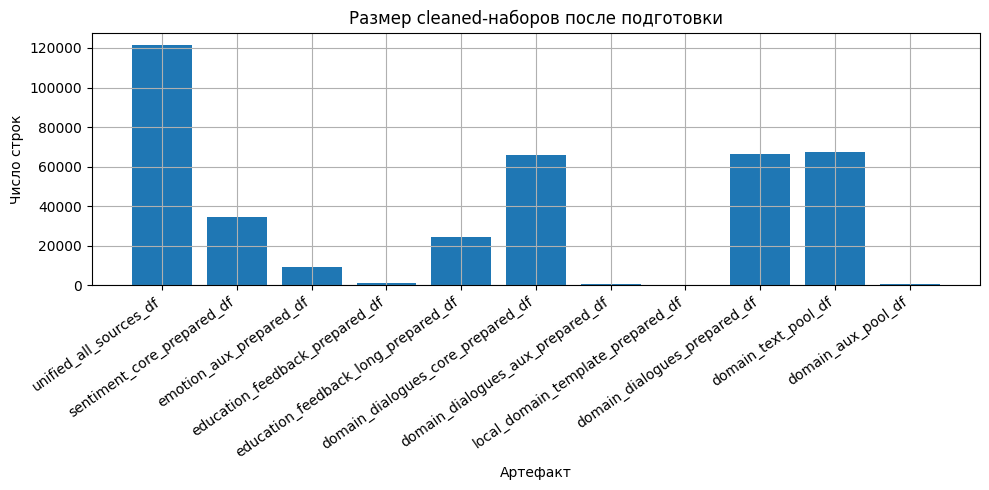

In [ ]:
plot_df = next_step_control_df.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["artifact_name"], plot_df["rows"])
plt.title("Размер cleaned-наборов после подготовки")
plt.xlabel("Артефакт")
plt.ylabel("Число строк")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "prepared_artifacts_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Итог этапа

После `02_data_preparation.ipynb` у нас должно быть:

1. Единая стандартизованная таблица всех источников.
2. Отдельно выделенное ядро `sentiment_core`.
3. Отдельный `emotion_aux` для CEDR.
4. Отдельный document-level и long-view для `student_feedback_ru`.
5. Отдельный набор доменных диалогов.
6. Общий доменный текстовый пул для следующего ноутбука.

In [ ]:
final_summary = {
    "all_sources_rows": int(len(unified_all_sources_df)),
    "sentiment_core_rows": int(len(sentiment_core_prepared_df)),
    "emotion_aux_rows": int(len(emotion_aux_prepared_df)),
    "education_feedback_rows": int(len(education_feedback_prepared_df)),
    "education_feedback_long_rows": int(len(education_feedback_long_prepared_df)),
    "domain_dialogues_core_rows": int(len(domain_dialogues_core_prepared_df)),
    "domain_dialogues_aux_rows": int(len(domain_dialogues_aux_prepared_df)),
    "local_domain_template_rows": int(len(local_domain_template_prepared_df)),
    "domain_dialogues_rows": int(len(domain_dialogues_prepared_df)),
    "domain_text_pool_rows": int(len(domain_text_pool_df)),
    "domain_aux_pool_rows": int(len(domain_aux_pool_df)),
    "unified_corpus_dir": str(UNIFIED_CORPUS_DIR),
    "cleaned_dir": str(CLEANED_DIR),
    "qc_reports_dir": str(QC_REPORTS_DIR),
}

final_summary

{'all_sources_rows': 121708,
 'sentiment_core_rows': 34331,
 'emotion_aux_rows': 9410,
 'education_feedback_rows': 1274,
 'education_feedback_long_rows': 24206,
 'domain_dialogues_core_rows': 66045,
 'domain_dialogues_aux_rows': 400,
 'local_domain_template_rows': 2,
 'domain_dialogues_rows': 66445,
 'domain_text_pool_rows': 67319,
 'domain_aux_pool_rows': 400,
 'unified_corpus_dir': '/content/drive/MyDrive/tutors_sentiment_project/02_data_interim/unified_corpus',
 'cleaned_dir': '/content/drive/MyDrive/tutors_sentiment_project/02_data_interim/cleaned',
 'qc_reports_dir': '/content/drive/MyDrive/tutors_sentiment_project/02_data_interim/qc_reports'}